# Generate Adversarial Network

## Import MNIST

In [7]:
import numpy as np
from pathlib import Path
import gzip

%load_ext autoreload
%autoreload 2

# Read info from compressed binary format
BASE_DIR = Path.cwd()

# Labels
label_path = BASE_DIR / "Data" / "MNIST" / 'train-labels-idx1-ubyte.gz'
with gzip.open(label_path, 'rb') as f:
    magic = int.from_bytes(f.read(4)) # First 4 bytes
    n_labels = int.from_bytes(f.read(4)) # Number of labels
    labels = np.frombuffer(f.read(), dtype=np.uint8) # Convert remaining bytes to numpy array

print(f"number of items according to file: {n_labels}")
print(f"actual number of items: {len(labels)}")

# Images
img_path = BASE_DIR / "Data" / "MNIST" / 'train-images-idx3-ubyte.gz'
with gzip.open(img_path, 'rb') as f:
    magic = int.from_bytes(f.read(4)) # First 4 bytes
    n_images = int.from_bytes(f.read(4)) # Number of images
    n_rows = int.from_bytes(f.read(4))
    n_cols = int.from_bytes(f.read(4))
    pixels = np.frombuffer(f.read(), dtype=np.uint8) # Convert remaining bytes to numpy array

print(f"number of images according to file: {n_labels}")
print(f"n_rows: {n_rows}")
print(f"n_cols: {n_cols}")
print(f"actual number of images: {len(pixels) // (n_rows * n_cols)}")

imgs = pixels.reshape(n_images, n_rows, n_cols)
print(f"number of reshapes images: {len(imgs)}")

number of items according to file: 60000
actual number of items: 60000
number of images according to file: 60000
n_rows: 28
n_cols: 28
actual number of images: 60000
number of reshapes images: 60000


In [1]:
import numpy as np

x = np.random.normal(size=[128])

x = x.reshape(1, 8, 4, 4) # batch_size, channels, rows, cols

x.shape

(1, 8, 4, 4)

In [8]:
imgs.shape

(60000, 28, 28)

In [3]:
from NNLibrary.network import Network
from NNLibrary.Layers.learnable import LinearLayer, ConvLayer, Layer
from NNLibrary.Layers.functional import MaxPool, Flatten, Dropout, Upsample
from NNLibrary.Layers.activations import Sigmoid, Softmax

network = Network(
    layers=[
        ConvLayer(in_channels=8, out_channels=4, kernel_size=3, padding=-1),
        Sigmoid(),
        Upsample(),
        ConvLayer(in_channels=4, out_channels=2, kernel_size=3, padding=-1),
        Sigmoid(),
        Upsample(),
        ConvLayer(in_channels=2, out_channels=1, kernel_size=3, padding=-1),
        # Flatten(),
        # LinearLayer(in_dim=256, out_dim=16*16),
        # Dropout(p=0.1),
        # Softmax(),
    ]
)

n_params = network.count_parameters()
print(f"Total parameter count: {n_params}")

Total parameter count: 385


In [4]:
out = network.forward(x)

# out = out.reshape(16, 16)

out.shape

(1, 1, 16, 16)

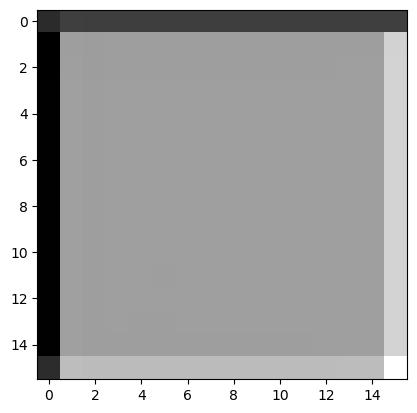

In [6]:
import matplotlib.pyplot as plt

plt.imshow(out[0, 0, :, :], cmap='gray')
# plt.imshow(out, cmap='gray')